In [4]:
tooth_images = [1, 10, 100, 101, 102, 103, 104, 105, 107, 108] # 選 10 張圖片

## Ratio 計算演算法研究：以 SAM pseudo-label mask 為基礎

`reports/models/sam_pseudo_labels/coco_annotations.json` 目前只有整顆牙齒的 mask（無 CEJ / root apex / crown tip 等專家 landmark，詳見 `preprocess.md` 第 6.5 節；segmentation 多為 polygon，個別為 uncompressed RLE，兩種格式都需處理）。因此這裡先不假設有 landmark，改為研究「純靠 segmentation mask 幾何」能否推算出一個近似 crown-to-root 的 ratio，作為之後與專家標註比較的 baseline。

**方法：主軸 + 寬度輪廓局部最窄點**

1. 對 mask 內所有前景像素做 PCA，取最大變異方向為牙齒長軸。
2. 將像素投影到長軸上，沿軸切成多個區段，量測每段垂直於長軸的寬度（寬度輪廓）。
3. 在寬度輪廓上找「左右都比它寬」的局部極小值（真正的頸部凹陷）近似 CEJ／牙頸部，並用 prominence 過濾雜訊；純粹單調收尖到根尖的形狀不會被誤判成頸部，找不到明顯頸部時直接回報「找不到」而非硬湊一個比例。
4. 以最窄點為界，分別計算牙冠端、牙根端沿長軸的長度，ratio = crown_length / root_length。

**限制（務必牢記）**：

- 這是純幾何近似，不是臨床 CRR；多根牙、影像遮蔽、鄰牙沾黏等情況容易讓最窄點落錯位置。
- pseudo-label mask 本身尚未經人工校正（見 `preprocess.md` 第 7 節），mask 邊界誤差會直接反映到 ratio 上。
- 這裡的輸出只用於觀察演算法行為、挑選需要優化的案例，不能當作醫學結論。

In [5]:
from pathlib import Path
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK TC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path.cwd()
COCO_PATH = PROJECT_ROOT / "reports/models/sam_pseudo_labels/coco_annotations.json"
IMAGES_DIR = PROJECT_ROOT / "data/processed"
OUTPUT_DIR = PROJECT_ROOT / "reports/models/ratio_algo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert COCO_PATH.exists(), f"找不到標註檔：{COCO_PATH}"
assert IMAGES_DIR.exists(), f"找不到影像目錄：{IMAGES_DIR}"

In [6]:
with open(COCO_PATH, encoding="utf-8") as f:
    coco = json.load(f)

images_by_filename = {img["file_name"]: img for img in coco["images"]}
annotations_by_image_id = {}
for ann in coco["annotations"]:
    annotations_by_image_id.setdefault(ann["image_id"], []).append(ann)

print(f"images: {len(coco['images'])}, annotations: {len(coco['annotations'])}")


def decode_uncompressed_rle(rle: dict, height: int, width: int) -> np.ndarray:
    """COCO uncompressed RLE：counts 為 column-major 交錯的 run-length（background 先）。"""
    rle_h, rle_w = rle["size"]
    flat = np.zeros(rle_h * rle_w, dtype=np.uint8)
    pos, value = 0, 0
    for run in rle["counts"]:
        if value:
            flat[pos: pos + run] = 1
        pos += run
        value = 1 - value
    mask = flat.reshape((rle_h, rle_w), order="F")
    if (rle_h, rle_w) != (height, width):
        mask = cv2.resize(mask, (width, height), interpolation=cv2.INTER_NEAREST)
    return mask.astype(bool)


def segmentation_to_mask(segmentation, height: int, width: int) -> np.ndarray:
    """coco_annotations.json 內大多是 polygon，但少數（如 107.png）是 uncompressed RLE，需分開處理。"""
    if isinstance(segmentation, dict):
        return decode_uncompressed_rle(segmentation, height, width)

    mask = np.zeros((height, width), dtype=np.uint8)
    for polygon in segmentation:
        points = np.array(polygon, dtype=np.float64).reshape(-1, 2)
        cv2.fillPoly(mask, [points.round().astype(np.int32)], color=1)
    return mask.astype(bool)


def load_tooth(stem: str):
    """依檔名（不含副檔名）取原圖與 coco 標註 mask；沒有標註時回傳 mask=None。"""
    file_name = f"{stem}.png"
    image_record = images_by_filename.get(file_name)
    if image_record is None:
        raise FileNotFoundError(f"coco_annotations.json 內找不到 {file_name}")

    image_path = IMAGES_DIR / file_name
    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"讀不到影像：{image_path}")
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    anns = annotations_by_image_id.get(image_record["id"], [])
    if not anns:
        return image_rgb, None
    # 每張圖目前僅標一顆目標牙齒；若未來有多顆，取面積最大者。
    largest_ann = max(anns, key=lambda a: a["area"])
    mask = segmentation_to_mask(largest_ann["segmentation"], image_record["height"], image_record["width"])
    return image_rgb, mask

images: 282, annotations: 281


In [7]:
def compute_axis_profile(mask: np.ndarray, n_bins: int = 100, smooth_window: int = 5) -> dict:
    """PCA 找牙齒長軸，沿軸切 n_bins 段，量測每段垂直於長軸的寬度。"""
    ys, xs = np.nonzero(mask)
    points = np.stack([xs, ys], axis=1).astype(np.float64)

    centroid = points.mean(axis=0)
    centered = points - centroid
    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    axis = eigvecs[:, np.argmax(eigvals)]
    axis = axis / np.linalg.norm(axis)
    perp = np.array([-axis[1], axis[0]])

    t = centered @ axis
    s = centered @ perp

    t_min, t_max = float(t.min()), float(t.max())
    bin_edges = np.linspace(t_min, t_max, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_idx = np.clip(np.digitize(t, bin_edges) - 1, 0, n_bins - 1)

    widths = np.zeros(n_bins)
    for i in range(n_bins):
        sel = s[bin_idx == i]
        widths[i] = sel.max() - sel.min() if sel.size else 0.0

    if smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        widths_smooth = np.convolve(widths, kernel, mode="same")
    else:
        widths_smooth = widths.copy()

    return {
        "centroid": centroid,
        "axis": axis,
        "t_min": t_min,
        "t_max": t_max,
        "bin_centers": bin_centers,
        "widths": widths,
        "widths_smooth": widths_smooth,
    }

In [8]:
def find_neck_and_ratio(profile: dict, edge_buffer_bins: int = 3, min_prominence_frac: float = 0.04) -> dict:
    """
    在寬度輪廓上找「真正的局部最窄點」（左右都比它寬，形成頸部凹陷）近似 CEJ／牙頸部。

    只單調收尖到根尖（多數牙根的常見形狀）不會被誤判成頸部：純變窄的序列在內部
    沒有局部極小值，最窄處只會落在排除的邊界 bin。早期版本用「排除兩端邊緣後取
    全域最小值」，遇到單調變窄的根尖時會被迫選在邊界附近，導致幾乎每張圖都得到
    同一個固定比例（約 7:1）的假結果。

    prominence 用「凹陷深度 / 兩側較低的那個局部最高寬度」表示（相對深度），而不是
    除以整顆牙齒的寬度全距：CEJ 的凹陷通常只比相鄰的牙冠或牙根窄 5–10%，遠小於
    牙冠最寬處與根尖幾乎收尖到 0 之間的全距，若用全距當分母會把真正的頸部濾掉。

    若整條輪廓都找不到夠明顯的頸部，回傳 found=False，不勉強給出比例。
    """
    widths = profile["widths_smooth"]
    centers = profile["bin_centers"]
    n = len(widths)

    candidates = []
    for i in range(edge_buffer_bins, n - edge_buffer_bins):
        if widths[i] <= 0:
            continue
        if widths[i] < widths[i - 1] and widths[i] < widths[i + 1]:
            left_max = widths[:i].max()
            right_max = widths[i:].max()
            ridge = min(left_max, right_max)
            if ridge <= 0:
                continue
            prominence_ratio = (ridge - widths[i]) / ridge
            candidates.append((prominence_ratio, i))

    valid = [c for c in candidates if c[0] >= min_prominence_frac]
    if not valid:
        return {
            "found": False,
            "t_neck": None,
            "root_end_t": None,
            "crown_end_t": None,
            "root_length": None,
            "crown_length": None,
            "ratio": float("nan"),
        }

    _, neck_idx = max(valid, key=lambda c: c[0])
    t_neck = float(centers[neck_idx])

    # 兩端邊緣寬度較小的一端視為逐漸收尖的牙根尖。
    head, tail = widths[:edge_buffer_bins], widths[-edge_buffer_bins:]
    width_min_side = head[head > 0].mean() if np.any(head > 0) else 0.0
    width_max_side = tail[tail > 0].mean() if np.any(tail > 0) else 0.0

    t_min, t_max = profile["t_min"], profile["t_max"]
    if width_min_side <= width_max_side:
        root_end_t, crown_end_t = t_min, t_max
    else:
        root_end_t, crown_end_t = t_max, t_min

    root_length = abs(t_neck - root_end_t)
    crown_length = abs(t_neck - crown_end_t)
    ratio = crown_length / root_length if root_length > 0 else float("nan")

    return {
        "found": True,
        "t_neck": t_neck,
        "root_end_t": root_end_t,
        "crown_end_t": crown_end_t,
        "root_length": root_length,
        "crown_length": crown_length,
        "ratio": ratio,
    }

In [9]:
def axis_point(profile: dict, t: float) -> np.ndarray:
    return profile["centroid"] + profile["axis"] * t


def draw_ratio_overlay(ax, image_rgb: np.ndarray, mask: np.ndarray, profile: dict, result: dict, title: str = ""):
    ax.imshow(image_rgb)
    ax.imshow(np.ma.masked_where(~mask, mask), alpha=0.35, cmap="autumn")

    if not result["found"]:
        ax.set_title(f"{title}\n(找不到明顯頸部)", fontsize=10, color="darkorange")
        ax.axis("off")
        return

    neck_xy = axis_point(profile, result["t_neck"])
    crown_xy = axis_point(profile, result["crown_end_t"])
    root_xy = axis_point(profile, result["root_end_t"])

    ax.plot([crown_xy[0], neck_xy[0]], [crown_xy[1], neck_xy[1]], color="dodgerblue", linewidth=2.5, label="crown")
    ax.plot([neck_xy[0], root_xy[0]], [neck_xy[1], root_xy[1]], color="lime", linewidth=2.5, label="root")
    ax.scatter(*neck_xy, color="yellow", edgecolors="black", s=60, zorder=5, label="neck (≈CEJ)")

    ax.set_title(f"{title}\nratio={result['ratio']:.2f}", fontsize=10)
    ax.axis("off")

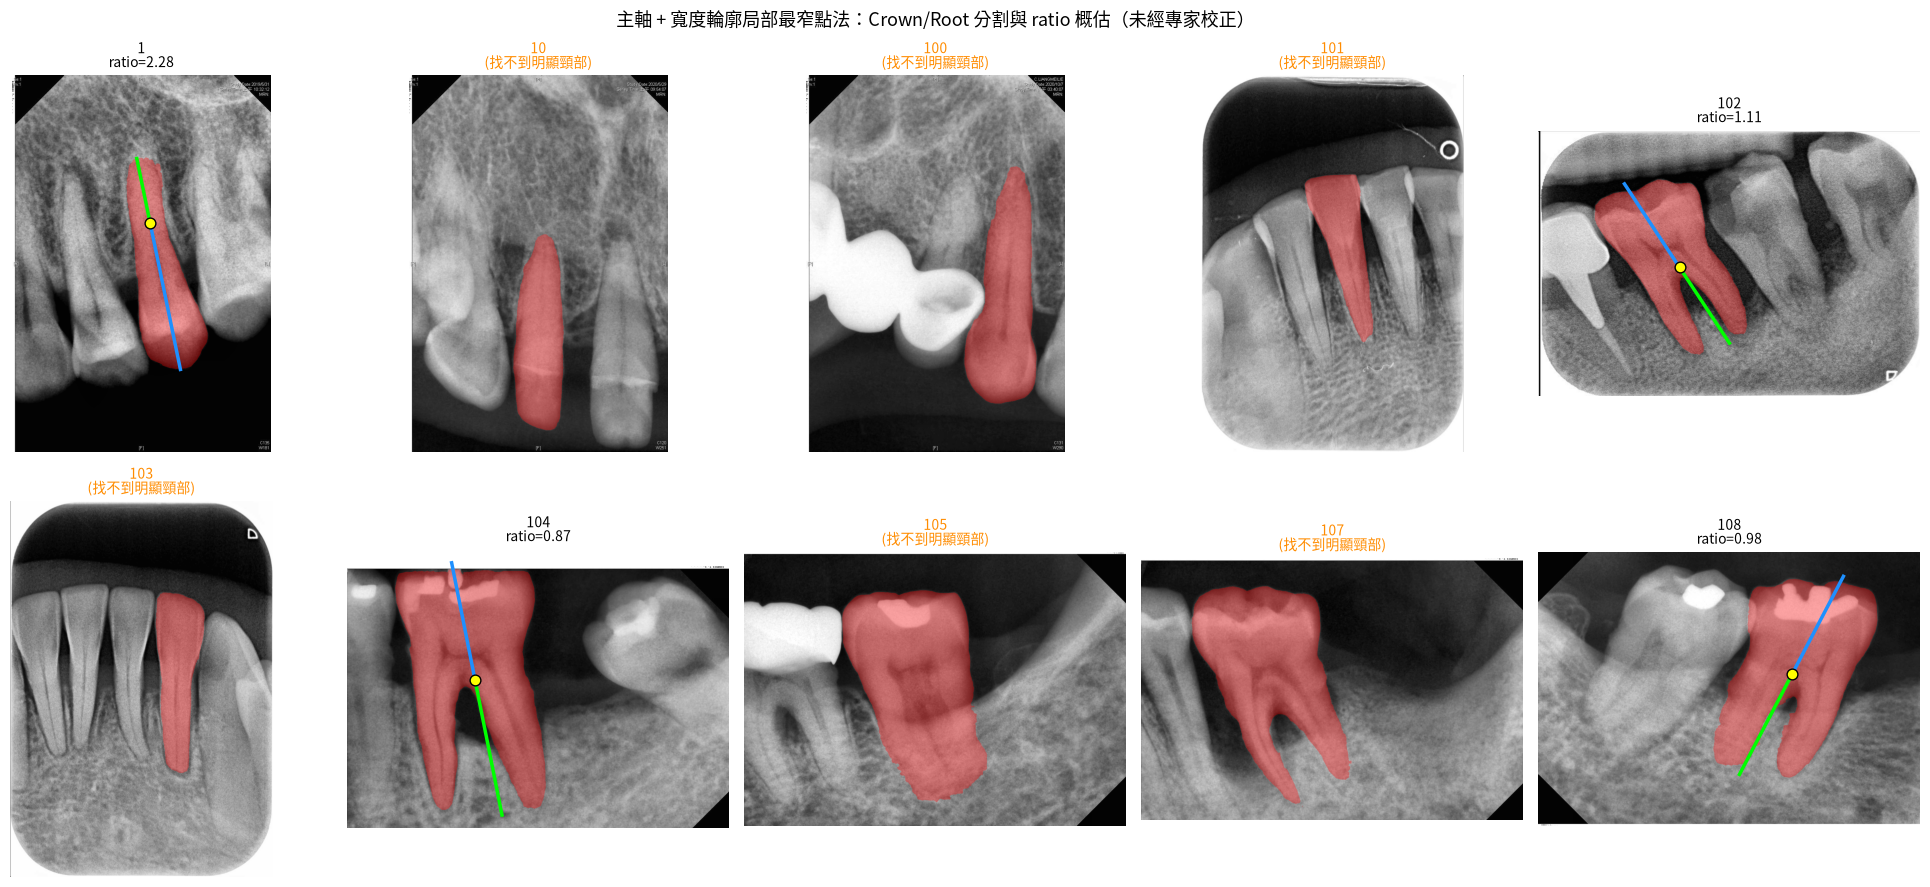

saved: /home/cliffyang/Program/Medical-CV/tooth_ratio/reports/models/ratio_algo/overlays_mosaic.png
{'stem': 1, 'found': True, 'crown_length': 477.6537945210815, 'root_length': 209.61785227184154, 'ratio': 2.278688524590164}
{'stem': 10, 'found': False, 'crown_length': None, 'root_length': None, 'ratio': nan}
{'stem': 100, 'found': False, 'crown_length': None, 'root_length': None, 'ratio': nan}
{'stem': 101, 'found': False, 'crown_length': None, 'root_length': None, 'ratio': nan}
{'stem': 102, 'found': True, 'crown_length': 207.8276996939042, 'root_length': 188.0345854373419, 'ratio': 1.105263157894737}
{'stem': 103, 'found': False, 'crown_length': None, 'root_length': None, 'ratio': nan}
{'stem': 104, 'found': True, 'crown_length': 375.76826502027217, 'root_length': 432.33553072224856, 'ratio': 0.869158878504673}
{'stem': 105, 'found': False, 'crown_length': None, 'root_length': None, 'ratio': nan}
{'stem': 107, 'found': False, 'crown_length': None, 'root_length': None, 'ratio': nan}


In [10]:
n_cols = 5
n_rows = -(-len(tooth_images) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.5 * n_rows))
axes = np.atleast_2d(axes)

ratio_table = []
for idx, stem in enumerate(tooth_images):
    ax = axes[idx // n_cols, idx % n_cols]
    try:
        image_rgb, mask = load_tooth(str(stem))
        if mask is None:
            ax.imshow(image_rgb)
            ax.set_title(f"{stem}\n(無標註)", fontsize=10)
            ax.axis("off")
            continue
        profile = compute_axis_profile(mask)
        result = find_neck_and_ratio(profile)
        draw_ratio_overlay(ax, image_rgb, mask, profile, result, title=str(stem))
        ratio_table.append({
            "stem": stem,
            "found": result["found"],
            "crown_length": result["crown_length"],
            "root_length": result["root_length"],
            "ratio": result["ratio"],
        })
    except Exception as exc:
        ax.set_title(f"{stem}\n[錯誤: {exc}]", fontsize=9, color="red")
        ax.axis("off")

for j in range(len(tooth_images), n_rows * n_cols):
    axes[j // n_cols, j % n_cols].axis("off")

fig.suptitle("主軸 + 寬度輪廓局部最窄點法：Crown/Root 分割與 ratio 概估（未經專家校正）", fontsize=13)
fig.tight_layout()

mosaic_path = OUTPUT_DIR / "overlays_mosaic.png"
fig.savefig(mosaic_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"saved: {mosaic_path}")
for row in ratio_table:
    print(row)

### 觀察重點與下一步

- 檢查 `overlays_mosaic.png` 中黃點（neck）是否落在視覺上合理的牙頸位置；系統性偏差通常代表邊緣搜尋比例 (`edge_margin_frac`) 或平滑窗口 (`smooth_window`) 需要調整。
- 多根牙（尤其臼齒）容易讓寬度輪廓在牙根分叉處出現次要低點，可能被誤判為 neck；可考慮之後改用「牙根分叉點以下再找最窄點」等規則。
- 下一步可將這裡算出的 `ratio_table` 與未來 CVAT 專家校正後的 CEJ/apex landmark 版本比較，量化這個純 mask 演算法的誤差。